# Beyond Breed: Age and Sterilization as Behavioral Predictors in Dogs

## Project Description

Dog behavior is often attributed to breed, but emerging research suggests that individual factors like age and sterilization status may be stronger predictors. This project performs a secondary analysis of the Darwin's Ark dataset (Morrill et al., *Science* 2022), one of 
the largest open-access surveys of dog behavior ever collected, covering tens of thousands of dogs across 8 quantified behavioral dimensions.

**Motivation:** Pet owners and veterinarians routinely make decisions about training approaches and lifestyle adjustments. These decisions are based on assumptions about how these factors impact dog behavior. Yet strong evidence for this is limited. By analyzing real owner-reported behavioral scores, this project aims to provide real and reliable data.

**Research Questions:**
1. Does sterilization status predict behavioral factor scores, and does the effect differ by sex?
2. How do the 8 behavioral factors change across age, and which are most sensitive to aging?

**Approach:** We use OLS regression models controlling for age, sex, and sterilization, with interaction terms to capture sex-specific sterilization effects. For aging, we fit quadratic models to capture non-linear trends across each behavioral dimension. Results are visualized as group mean plots with confidence intervals and age-bin trend lines.

**Dataset:** Morrill et al. (2022). Darwin's Ark. https://doi.org/10.5061/dryad.g4f4qrfr0

In [1]:
!pip3 install statsmodels


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
from scipy.stats import f as f_dist

In [3]:
# Load the files we need
dogs = pd.read_csv('DarwinsArk_20191115_dogs.csv')
scores = pd.read_csv('DarwinsArk_20191115_factor_scores.csv')

In [4]:
def summarize_factor_regression(df, factor_num, formula, factor_names):
    """
    Fits an OLS regression for a single behavioral factor and prints a summary.
    
    Parameters:
        df          : the cleaned DataFrame (df_clean)
        factor_num  : integer 1–8 identifying the factor
        formula     : OLS formula string, e.g. 'score ~ age + sex_bin + sterilized_bin'
        factor_names: dict mapping factor number to human-readable name
    
    Returns:
        result : fitted statsmodels OLS result object
    """
    factor_df = df[df['factor'] == factor_num].copy()
    factor_name = factor_names.get(factor_num, f'Factor {factor_num}')
    
    model = smf.ols(formula, data=factor_df).fit()
    
    print(f"=== {factor_name} (Factor {factor_num}) ===")
    print(f"R²: {model.rsquared:.4f}   Adj. R²: {model.rsquared_adj:.4f}   N: {int(model.nobs)}")
    print(model.params.to_string())
    print(f"p-values:\n{model.pvalues.to_string()}")
    print()
    
    return model

In [5]:
df = scores.merge(dogs[['id', 'sex', 'sterilized']], left_on='dog', right_on='id', how='left')

## Data prep and cleaning

In [6]:
factor_names = {
    1: 'Human Sociability',
    2: 'Arousal Level',
    3: 'Toy-directed Motor Patterns',
    4: 'Biddability',
    5: 'Agonistic Threshold',
    6: 'Dog Sociability',
    7: 'Environmental Engagement',
    8: 'Proximity Seeking'
}
df['factor_name'] = df['factor'].map(factor_names)

In [7]:
print(df['sex'].unique())
print(df['sterilized'].unique())
print(df['factor'].unique())
print(df['age'].describe())

<StringArray>
['female', 'male', nan]
Length: 3, dtype: str
<StringArray>
['yes', 'no', nan]
Length: 3, dtype: str
[1 2 3 4 5 6 7 8]
count    105485.000000
mean          5.780528
std           3.883291
min           0.000891
25%           2.514926
50%           5.029565
75%           8.498975
max          30.834955
Name: age, dtype: float64


In [8]:
df_clean = df.dropna(subset=['sex', 'sterilized'])
df_clean = df_clean[df_clean['age'] <= 20]
df_clean = df_clean.drop(columns=['id', 'score.norm', 'discovery'])

In [9]:
df_clean

,dog,factor,score,age,sex,sterilized,factor_name
0,3,1,0.4880,5.453216,female,yes,Human Sociability
1,3,2,-0.1910,5.453207,female,yes,Arousal Level
2,3,3,0.0473,5.453203,female,yes,Toy-directed Motor Patterns
3,3,4,0.0357,5.453213,female,yes,Biddability
4,3,5,0.4170,5.453216,female,yes,Agonistic Threshold
...,...,...,...,...,...,...,...
128611,24353,4,0.8320,6.001957,female,yes,Biddability
128612,24353,5,0.5750,6.001964,female,yes,Agonistic Threshold
128613,24353,6,0.3680,6.001976,female,yes,Dog Sociability
128614,24353,7,0.0891,6.001970,female,yes,Environmental Engagement


## Does sterilization status predict behavioral factor scores, and does the effect differ between male and female dogs?

In [10]:
# one hot encoding
df_clean['sterilized_bin'] = (df_clean['sterilized'] == 'yes').astype(int)
df_clean['sex_bin'] = (df_clean['sex'] == 'male').astype(int)

In [11]:
# Check group sizes per factor (just factor 1 as representative)
group_counts = (
    df_clean[df_clean['factor'] == 1]
    .groupby(['sex', 'sterilized'])
    .size()
    .reset_index(name='n')
)
print(group_counts)

      sex sterilized     n
0  female         no   475
1  female        yes  5671
2    male         no   678
3    male        yes  5404


In [12]:
results = []

for factor_num in range(1, 9):
    factor_df = df_clean[df_clean['factor'] == factor_num].copy()
    factor_name = factor_df['factor_name'].iloc[0]
    
    model = smf.ols(
        'score ~ age + sex_bin + sterilized_bin + sex_bin:sterilized_bin',
        data=factor_df
    ).fit()
    
    results.append({
        'factor':            factor_num,
        'factor_name':       factor_name,
        # Main effects
        'coef_sterilized':   model.params['sterilized_bin'],
        'pval_sterilized':   model.pvalues['sterilized_bin'],
        'coef_sex':          model.params['sex_bin'],
        'pval_sex':          model.pvalues['sex_bin'],
        # Interaction: does sterilization effect differ by sex?
        'coef_interaction':  model.params['sex_bin:sterilized_bin'],
        'pval_interaction':  model.pvalues['sex_bin:sterilized_bin'],
        # Model fit
        'r_squared':         model.rsquared,
        'n':                 int(model.nobs)
    })

results_df = pd.DataFrame(results)

# Apply Bonferroni correction across 8 tests
results_df['pval_sterilized_adj']  = (results_df['pval_sterilized']  * 8).clip(upper=1)
results_df['pval_sex_adj']         = (results_df['pval_sex']         * 8).clip(upper=1)
results_df['pval_interaction_adj'] = (results_df['pval_interaction'] * 8).clip(upper=1)

print(results_df[[
    'factor_name',
    'coef_sterilized', 'pval_sterilized_adj',
    'coef_sex',        'pval_sex_adj',
    'coef_interaction','pval_interaction_adj',
    'r_squared'
]].round(4).to_string())

                   factor_name  coef_sterilized  pval_sterilized_adj  coef_sex  pval_sex_adj  coef_interaction  pval_interaction_adj  r_squared
0            Human Sociability          -0.0961               0.2597    0.1150        0.3132           -0.0227                1.0000     0.0068
1                Arousal Level           0.0250               1.0000    0.0012        1.0000           -0.0163                1.0000     0.0668
2  Toy-directed Motor Patterns           0.0174               1.0000   -0.0374        1.0000            0.0374                1.0000     0.1171
3                  Biddability           0.0185               1.0000   -0.0677        1.0000            0.1003                0.4102     0.0029
4          Agonistic Threshold           0.0736               0.5396    0.0574        1.0000           -0.2030                0.0009     0.0066
5              Dog Sociability          -0.0434               1.0000    0.1644        0.0085           -0.0352                1.0000    

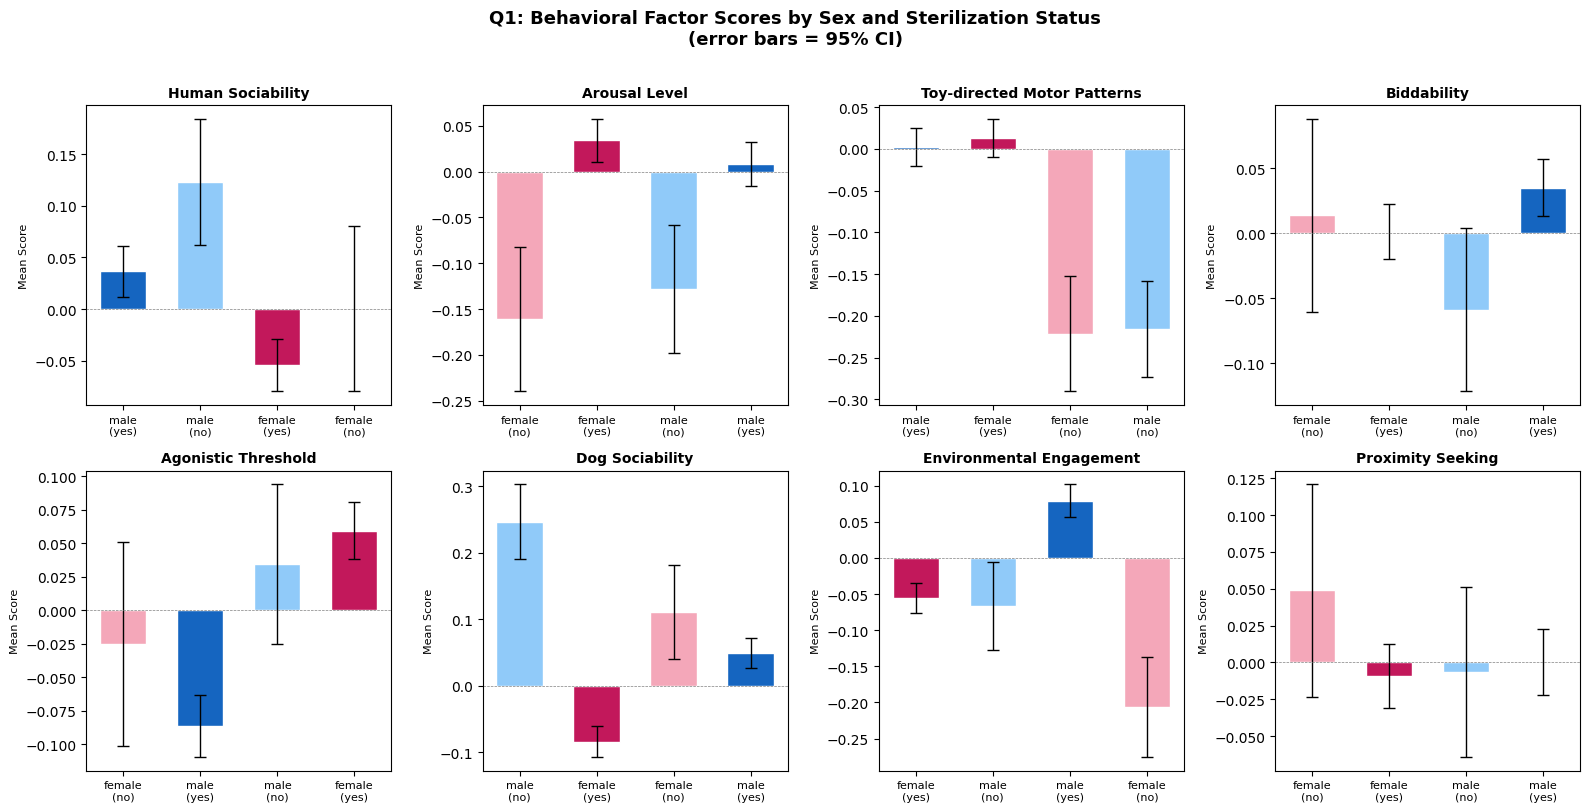

In [13]:
# Compute group means and SE per factor × sex × sterilized
summary = (
    df_clean
    .groupby(['factor_name', 'factor', 'sex', 'sterilized'])['score']
    .agg(['mean', 'sem', 'count'])
    .reset_index()
)
summary.columns = ['factor_name', 'factor', 'sex', 'sterilized', 'mean', 'sem', 'n']
summary = summary.sort_values('factor')

# Create a label combining sex + sterilized for the x-axis
summary['group'] = summary['sex'] + '\n(' + summary['sterilized'] + ')'

fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=False)
axes = axes.flatten()

palette = {
    'female\n(no)':  '#f4a7b9',
    'female\n(yes)': '#c2185b',
    'male\n(no)':    '#90caf9',
    'male\n(yes)':   '#1565c0'
}

for i, factor_num in enumerate(range(1, 9)):
    ax = axes[i]
    data = summary[summary['factor'] == factor_num]
    
    bars = ax.bar(
        data['group'], data['mean'],
        color=[palette[g] for g in data['group']],
        width=0.6, edgecolor='white'
    )
    ax.errorbar(
        x=range(len(data)), y=data['mean'],
        yerr=data['sem'] * 1.96,
        fmt='none', color='black', capsize=4, linewidth=1
    )
    
    factor_name = data['factor_name'].iloc[0]
    ax.set_title(factor_name, fontsize=10, fontweight='bold')
    ax.set_ylabel('Mean Score', fontsize=8)
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelsize=8)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')

plt.suptitle(
    'Q1: Behavioral Factor Scores by Sex and Sterilization Status\n(error bars = 95% CI)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('Q1_sex_sterilization_behavioral_factors.png', dpi=150, bbox_inches='tight')
plt.show()

Sterilization status is a weak predictor of behavioral factor scores. It reaches significance for only one factor (Proximity Seeking) and only as a main effect. Sex alone predicts Dog Sociability. The most meaningful result is the sex × sterilization interaction on Agonistic Threshold — sterilized males become more assertive relative to other groups — which is both statistically robust and biologically plausible given the role of testosterone in aggression modulation.
All R² values are below 0.12, confirming the paper's core finding: individual dog characteristics explain very little behavioral variance overall.
Several factors — notably Arousal Level and Toy-directed Motor Patterns — showed visually large group differences in the bar chart but did not survive Bonferroni correction. This does not mean those effects are absent; it means we cannot confidently rule out that they arose by chance given the number of tests run (n=8). Whether age, sterilization, or their combination drives those patterns would require a dedicated model comparison — comparing coefficients with and without age as a covariate — which was not performed here and represents a limitation of the current analysis.

## How do each of the 8 behavioral factors change across age, and which are most sensitive to aging?

In [14]:
# Quick look at age spread
print(df_clean['age'].describe())

count    104999.000000
mean          5.765836
std           3.859208
min           0.000891
25%           2.506842
50%           5.023947
75%           8.482893
max          19.877456
Name: age, dtype: float64


In [15]:
# Create age bins for plotting (every 2 years)
bins = np.arange(0, 21, 2)
labels = [f'{b}–{b+2}' for b in bins[:-1]]
df_clean['age_bin'] = pd.cut(df_clean['age'], bins=bins, labels=labels, right=False)

# Check how many dogs per age bin (using factor 1 as representative)
bin_counts = (
    df_clean[df_clean['factor'] == 1]
    .groupby('age_bin', observed=True)['dog']
    .count()
    .reset_index(name='n')
)
print(bin_counts)

  age_bin     n
0     0–2  2288
1     2–4  2490
2     4–6  2157
3     6–8  1734
4    8–10  1515
5   10–12  1083
6   12–14   599
7   14–16   284
8   16–18    64
9   18–20    14


In [16]:
age_results = []

for factor_num in range(1, 9):
    factor_df = df_clean[df_clean['factor'] == factor_num].copy()
    factor_name = factor_df['factor_name'].iloc[0]

    # Quadratic model: score ~ age + age² + sex + sterilized
    model_full = smf.ols(
        'score ~ age + I(age**2) + sex_bin + sterilized_bin',
        data=factor_df
    ).fit()

    # Baseline model without age (to measure age contribution)
    model_base = smf.ols(
        'score ~ sex_bin + sterilized_bin',
        data=factor_df
    ).fit()

    # How much R² does age alone add?
    r2_gain = model_full.rsquared - model_base.rsquared

    # Predicted range across age span (practical effect size)
    age_range = pd.DataFrame({
        'age':          np.linspace(0.5, 18, 100),
        'sex_bin':      0,   # hold at female
        'sterilized_bin': 1  # hold at sterilized (majority group)
    })
    age_range['age_sq'] = age_range['age'] ** 2
    predicted = model_full.predict(age_range)
    pred_range = predicted.max() - predicted.min()

    age_results.append({
        'factor':         factor_num,
        'factor_name':    factor_name,
        'coef_age':       model_full.params['age'],
        'coef_age_sq':    model_full.params['I(age ** 2)'],
        'pval_age':       model_full.pvalues['age'],
        'pval_age_sq':    model_full.pvalues['I(age ** 2)'],
        'r2_full':        model_full.rsquared,
        'r2_gain':        r2_gain,        # R² added by age terms
        'pred_range':     pred_range,     # practical effect size
        'n':              int(model_full.nobs)
    })

age_df = pd.DataFrame(age_results)

# Bonferroni correction across 8 factors
age_df['pval_age_adj']    = (age_df['pval_age']    * 8).clip(upper=1)
age_df['pval_age_sq_adj'] = (age_df['pval_age_sq'] * 8).clip(upper=1)

print(age_df[[
    'factor_name', 'coef_age', 'coef_age_sq',
    'pval_age_adj', 'pval_age_sq_adj',
    'r2_full', 'r2_gain', 'pred_range'
]].round(4).to_string())

                   factor_name  coef_age  coef_age_sq  pval_age_adj  pval_age_sq_adj  r2_full  r2_gain  pred_range
0            Human Sociability   -0.0248       0.0029        0.0077           0.0000   0.0093   0.0062      0.5321
1                Arousal Level    0.1022      -0.0030        0.0000           0.0000   0.0697   0.0668      0.8137
2  Toy-directed Motor Patterns    0.1327      -0.0039        0.0000           0.0000   0.1223   0.1169      1.0525
3                  Biddability   -0.0767       0.0047        0.0000           0.0000   0.0100   0.0096      0.4571
4          Agonistic Threshold   -0.0231       0.0019        0.0055           0.0002   0.0068   0.0016      0.2831
5              Dog Sociability   -0.1593       0.0076        0.0000           0.0000   0.0758   0.0661      0.7536
6     Environmental Engagement   -0.0435       0.0043        0.0000           0.0000   0.0212   0.0125      0.7194
7            Proximity Seeking   -0.0190       0.0027        0.0392           0.

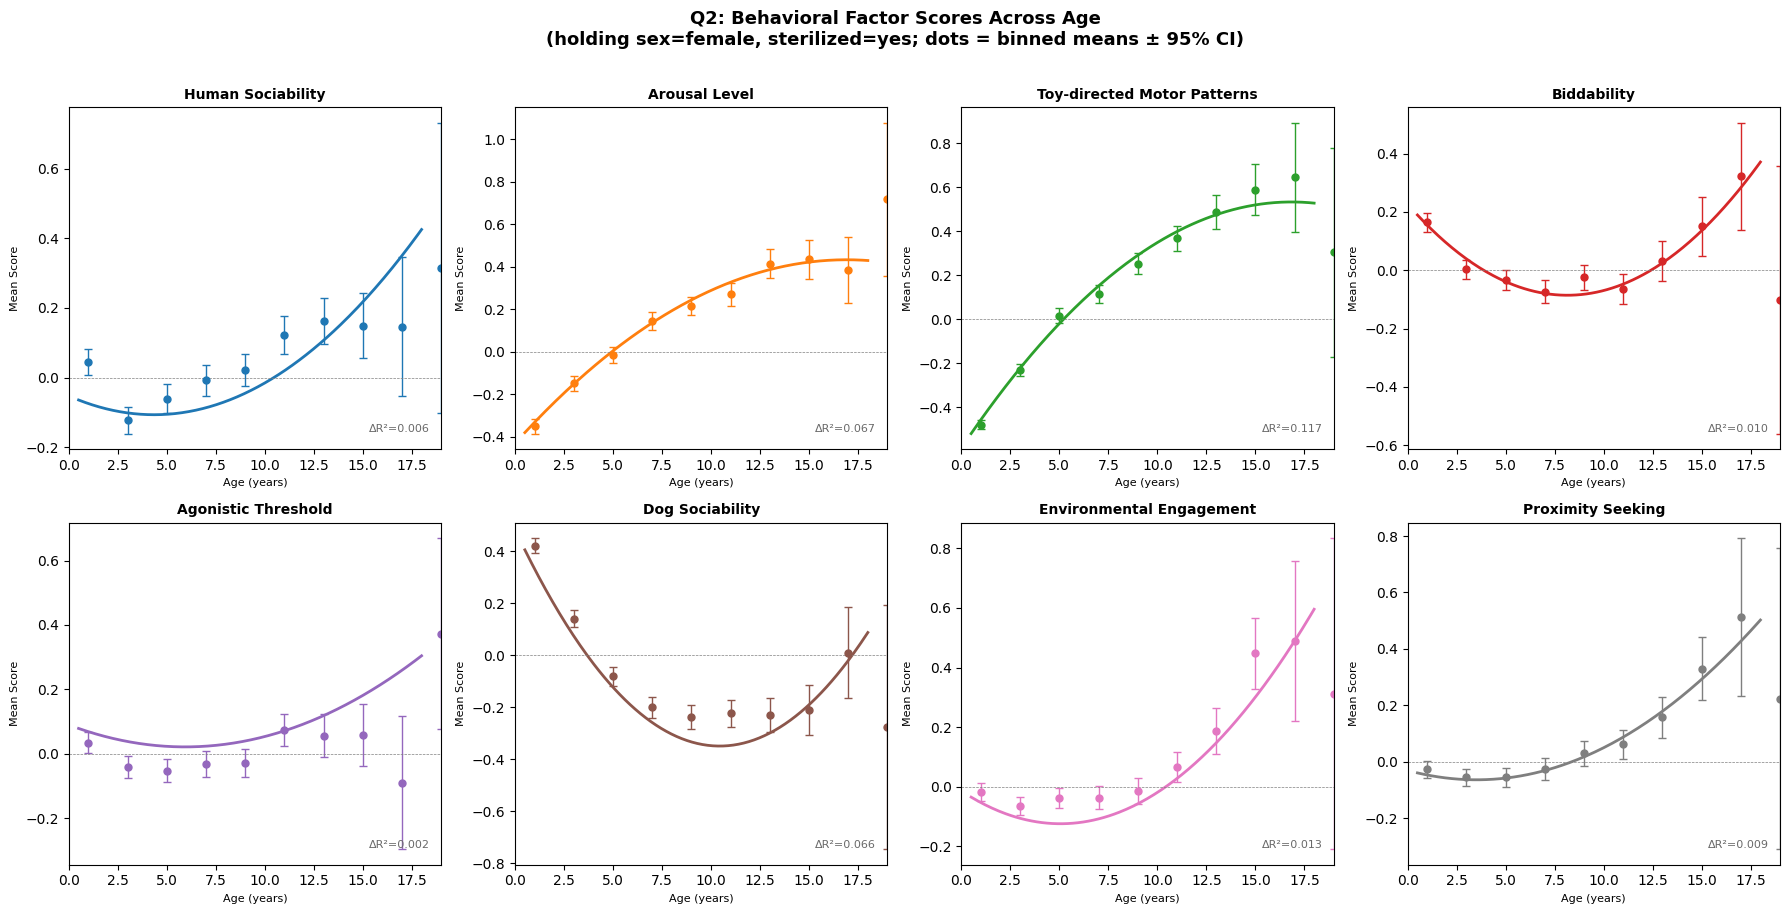

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9), sharey=False)
axes = axes.flatten()

colors = cm.tab10.colors

for i, factor_num in enumerate(range(1, 9)):
    ax = axes[i]
    factor_df = df_clean[df_clean['factor'] == factor_num].copy()
    factor_name = factor_df['factor_name'].iloc[0]

    # Binned means ± SE for scatter
    binned = (
        factor_df.groupby('age_bin', observed=True)['score']
        .agg(['mean', 'sem', 'count'])
        .reset_index()
    )
    # Midpoint of each bin for x-axis
    bin_mids = [float(str(b).split('–')[0]) + 1 for b in binned['age_bin']]
    
    ax.errorbar(
        bin_mids, binned['mean'],
        yerr=binned['sem'] * 1.96,
        fmt='o', color=colors[i], markersize=5,
        capsize=3, linewidth=1, label='Mean ± 95% CI'
    )

    # Fitted quadratic curve
    model = smf.ols(
        'score ~ age + I(age**2) + sex_bin + sterilized_bin',
        data=factor_df
    ).fit()

    age_seq = pd.DataFrame({
        'age':            np.linspace(0.5, 18, 200),
        'sex_bin':        0,
        'sterilized_bin': 1
    })
    fitted = model.predict(age_seq)
    
    ax.plot(age_seq['age'], fitted, color=colors[i],
            linewidth=2, linestyle='-', label='Quadratic fit')
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')

    # Annotate with R² gain from age
    r2g = age_df.loc[age_df['factor'] == factor_num, 'r2_gain'].values[0]
    ax.text(0.97, 0.05, f'ΔR²={r2g:.3f}',
            transform=ax.transAxes, ha='right',
            fontsize=8, color='dimgray')

    ax.set_title(factor_name, fontsize=10, fontweight='bold')
    ax.set_xlabel('Age (years)', fontsize=8)
    ax.set_ylabel('Mean Score', fontsize=8)
    ax.set_xlim(0, 19)

plt.suptitle(
    'Q2: Behavioral Factor Scores Across Age\n(holding sex=female, sterilized=yes; dots = binned means ± 95% CI)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('Q2_aging_behavioral_factors.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Example: summarize sterilization model for Factor 5 (Agonistic Threshold)
summarize_factor_regression(
    df_clean,
    factor_num=5,
    formula='score ~ age + sex_bin + sterilized_bin + sex_bin:sterilized_bin',
    factor_names=factor_names
)

=== Agonistic Threshold (Factor 5) ===
R²: 0.0066   Adj. R²: 0.0063   N: 13435
Intercept                -0.037246
age                       0.003806
sex_bin                   0.057432
sterilized_bin            0.073591
sex_bin:sterilized_bin   -0.202991
p-values:
Intercept                 0.336820
age                       0.057743
sex_bin                   0.250333
sterilized_bin            0.067452
sex_bin:sterilized_bin    0.000110



All 8 factors change significantly with age, but the magnitude varies enormously. Toy-directed Motor Patterns, Arousal Level, and Dog Sociability are by far the most age-sensitive — together they tell a coherent story of dogs becoming calmer, less playful, and less dog-social as they leave puppyhood. The three factors least sensitive to aging (Biddability, Proximity Seeking, Agonistic Threshold) still reach significance but explain under 1% of additional variance — statistically detectable in a large dataset but not practically meaningful.
The dominant aging pattern is a shift from high energy and social enthusiasm in puppyhood toward calm, human-oriented engagement in old age — with adolescence (roughly ages 5–10) representing a transitional dip in sociability and trainability across multiple factors simultaneously.